# Trabajo Práctico: Desarrollo de un Modelo Predictivo Vinculado al TFM
---
### Máster en Big Data & Business Intelligence 2025/2026  
### Asignatura 7: Modelado Predictivo con Machine Learning 
**Universidad:** Next Educación  
**Curso académico:** Febrero 2026  
**Alumno:** Sergio Solórzano Alfaro  
**Fecha de entrega:** 4 de Octubre, 2026 

---

Este cuaderno está dividido en dos secciones de contenido:
1. El conjunto de consultas y resultados que se utilizaron para **análisis preeliminar de datos** presentes en la base de datos construida a partir de información histórica de SICOP (proveedores, instituciones, carteles, ofertas y adjudicaciones).
2. Un conjunto de consultas para la **construcción del data set final con el que se entrenó un modelo predictivo de clasificación (Random Forest)** para calcular la probabilidad de adjudicación que tendrán ofertas presentadas pero que aún no han sido adjudicadas. En esta misma sección se evaluá y selecciona el mejor conjunto de hiperparámetros para el modelo y además se grafican los resultados de evaluación del modelo.

---

## 1. Análisis preeliminar de datos

Cómo primer paso, será necesario descargar, en su computadora, la base de datos publicada en el siguiente release del repositorio: [Base de datos SICOP](https://github.com/ssolorzanocr/Modelo_predictivo_SICOP/releases/download/datos_actuales_sicop/sicop.duckdb)  
Para efectos de este cuaderno, la base de datos utilizada posee <u>registros que comprenden un periodo desde Enero 2025 hasta Septiembre del 2026</u> (21 meses).

Luego, debemos instalar las librerías para ejecutar los fragmentos de código python en este cuaderno de Jupiter:  
`python -m pip install --upgrade pip`
`pip install duckdb pandas matplotlib scikit-learn`

Ahora, crearemos una conexión a la base de datos local en el ordenador e imprimimos las tablas disponibles del modelo de datos.

In [ ]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from dotenv import load_dotenv
import os

load_dotenv()

RUTA_BASE_DE_DATOS = os.getenv("RUTA_DATOS")
print(f"Ruta de la base de datos: {RUTA_BASE_DE_DATOS}")

con = duckdb.connect(
    RUTA_BASE_DE_DATOS,
    read_only=True
)

Ruta de la base de datos: localdata\sicop.duckdb


Exploramos el contenido de la base de datos a nivel general.  
Observamos que hay dos schemas en la base datos. Para efectos de este cuaderno solo nos interesa el schema llamado 'final'.  

In [ ]:
con.sql("SHOW ALL TABLES").df()

,database,schema,name,column_names,column_types,temporary
0,sicop,final,dim_instituciones,"[cedula, nombre_institucion, zona_geo_inst, fe...","[VARCHAR, VARCHAR, VARCHAR, DATE, BIGINT]",False
1,sicop,final,dim_productos,"[cod_producto, descripcion_producto, segmento,...","[BIGINT, VARCHAR, INTEGER, VARCHAR]",False
2,sicop,final,dim_proveedores,"[cedula_proveedor, nombre_proveedor, tipo_prov...","[VARCHAR, VARCHAR, VARCHAR, VARCHAR, VARCHAR, ...",False
3,sicop,final,fact_lineas_adjudicadas,"[nro_sicop, nro_linea, nro_oferta, cedula_inst...","[VARCHAR, VARCHAR, VARCHAR, VARCHAR, VARCHAR, ...",False
4,sicop,final,fact_lineas_carteles,"[nro_sicop, numero_linea, numero_partida, cedu...","[VARCHAR, VARCHAR, VARCHAR, VARCHAR, DATE, VAR...",False
5,sicop,final,fact_lineas_ofertas,"[nro_sicop, nro_oferta, nro_linea, cedula_prov...","[VARCHAR, VARCHAR, VARCHAR, VARCHAR, DATE, VAR...",False
6,sicop,final,predicciones_adjudicacion,"[nro_sicop, nro_linea, nro_oferta, cedula_prov...","[VARCHAR, VARCHAR, VARCHAR, VARCHAR, DOUBLE]",False
7,sicop,staging,dim_instituciones,"[cedula, nombre_institucion, zona_geo_inst, fe...","[VARCHAR, VARCHAR, VARCHAR, VARCHAR, VARCHAR]",False
8,sicop,staging,dim_proveedores,"[cedula_proveedor, nombre_proveedor, tipo_prov...","[VARCHAR, VARCHAR, VARCHAR, VARCHAR, VARCHAR, ...",False
9,sicop,staging,fact_adjudicaciones,"[nro_sicop, cedula, numero_procedimiento, desc...","[VARCHAR, VARCHAR, VARCHAR, VARCHAR, VARCHAR, ...",False


Mostramos ahora las columnas de datos en el schema final:

In [ ]:
pd.set_option("display.max_rows", None)

con.sql("""
    SELECT
        database_name,
        schema_name,
        table_name,
        column_name,
        data_type
    FROM duckdb_columns()
    WHERE NOT internal and schema_name = 'final'
    ORDER BY table_name
""").df()

,database_name,schema_name,table_name,column_name,data_type
0,sicop,final,dim_instituciones,cedula,VARCHAR
1,sicop,final,dim_instituciones,nombre_institucion,VARCHAR
2,sicop,final,dim_instituciones,zona_geo_inst,VARCHAR
3,sicop,final,dim_instituciones,fecha_ingreso,DATE
4,sicop,final,dim_instituciones,proveedores_adjudicados_distintos,BIGINT
5,sicop,final,dim_productos,cod_producto,BIGINT
6,sicop,final,dim_productos,descripcion_producto,VARCHAR
7,sicop,final,dim_productos,segmento,INTEGER
8,sicop,final,dim_productos,nombre_segmento,VARCHAR
9,sicop,final,dim_proveedores,porcentaje_exito,DOUBLE


Exploremos la cantidad de registros y cantidad de valores nulos para cada tabla en el periodo estudiado.

In [ ]:
for table in con.sql("""
    SELECT
        database_name,
        schema_name,
        table_name,
        column_name,
        data_type
    FROM duckdb_columns()
    WHERE NOT internal and schema_name = 'final'
    ORDER BY table_name
    """).df().table_name.unique():
    print("__________________________________")
    print(f"Registros en final.{table}: {con.sql(f'SELECT COUNT(*) AS total_registros FROM final.{table}').df().values[0]}")
    print(f"Columnas en final.{table}: {con.sql(f'SELECT COUNT(*) AS total_columnas FROM duckdb_columns() WHERE schema_name = \'final\' AND table_name = \'{table}\'').df().values[0]}")
    print(f"cantidad de valores nulos por columna en final.{table}:")
    for column in con.sql(f"SELECT column_name FROM duckdb_columns() WHERE schema_name = 'final' AND table_name = '{table}'").df().column_name:
        nulos = con.sql(f"SELECT COUNT(*) AS nulos FROM final.{table} WHERE {column} IS NULL").df().values[0]
        print(f"  - {column}: {nulos}")


__________________________________
Registros en final.dim_instituciones: [690]
Columnas en final.dim_instituciones: [5]
cantidad de valores nulos por columna en final.dim_instituciones:
  - cedula: [0]
  - nombre_institucion: [0]
  - zona_geo_inst: [0]
  - fecha_ingreso: [7]
  - proveedores_adjudicados_distintos: [0]
__________________________________
Registros en final.dim_productos: [104759]
Columnas en final.dim_productos: [4]
cantidad de valores nulos por columna en final.dim_productos:
  - cod_producto: [0]
  - descripcion_producto: [3406]
  - segmento: [0]
  - nombre_segmento: [0]
__________________________________
Registros en final.dim_proveedores: [58406]
Columnas en final.dim_proveedores: [8]
cantidad de valores nulos por columna en final.dim_proveedores:
  - cedula_proveedor: [0]
  - nombre_proveedor: [0]
  - tipo_proveedor: [0]
  - tamano_proveedor: [0]
  - zona_geo_prov: [0]
  - fecha_registro: [3]
  - porcentaje_exito: [54027]
  - productos_distintos_ofertados: [0]
______

---
Estudiemos el comportamiento de las **instituciones**.  
Para empezar, consultamos la cantidad de instituciones que han publicado un cartel durante el periodo de estudio.

In [ ]:
con.sql("""
    SELECT COUNT(DISTINCT cedula_institucion) AS cantidad_instituciones_activas
    FROM final.fact_lineas_carteles
""").df()

,cantidad_instituciones_activas
0,379


Cantidad de carteles publicados mensualmente por institución:

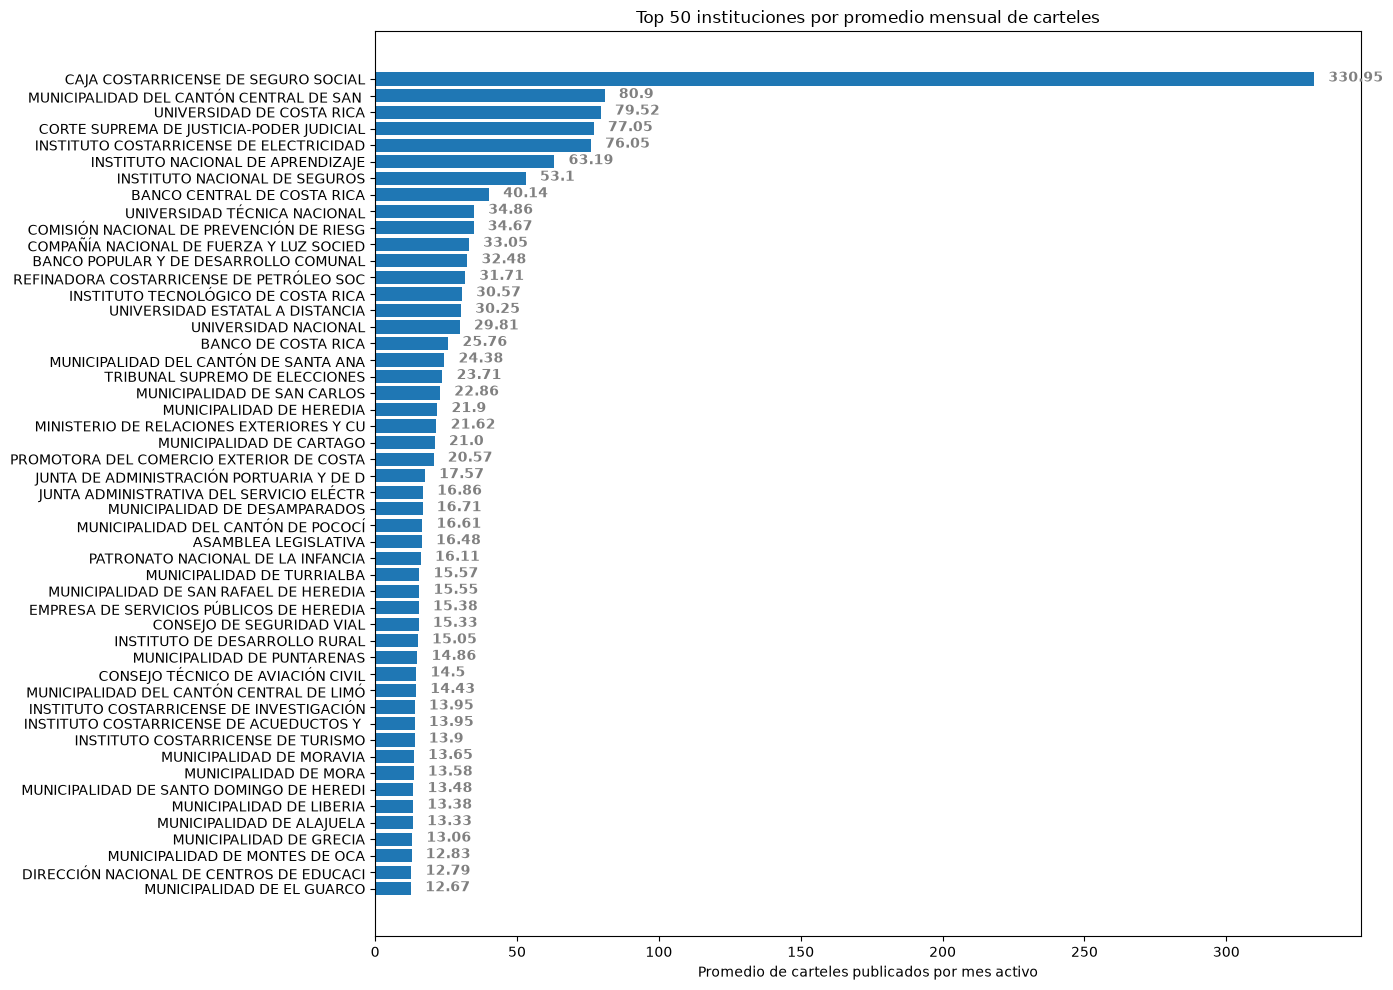

In [ ]:
df_promedio_mensual = con.execute("""
    WITH carteles_por_mes AS (
        SELECT
            c.cedula_institucion,
            date_trunc('month', c.fecha_publicacion) AS mes,
            COUNT(DISTINCT c.nro_sicop) AS carteles_mes
        FROM final.fact_lineas_carteles c
        WHERE c.fecha_publicacion IS NOT NULL
        GROUP BY c.cedula_institucion, date_trunc('month', c.fecha_publicacion)
    )
    SELECT
        cpm.cedula_institucion,
        i.nombre_institucion,
        ROUND(AVG(cpm.carteles_mes), 2) AS promedio_carteles_mes,
        COUNT(*) AS meses_con_actividad,
        SUM(cpm.carteles_mes) AS total_carteles
    FROM carteles_por_mes cpm
    LEFT JOIN final.dim_instituciones i ON i.cedula = cpm.cedula_institucion
    GROUP BY cpm.cedula_institucion, i.nombre_institucion
    ORDER BY promedio_carteles_mes DESC
""").df()

top20 = df_promedio_mensual.head(50).copy()
etiquetas = top20["nombre_institucion"].fillna(top20["cedula_institucion"]).str.slice(0, 40)

fig, ax = plt.subplots(figsize=(14, 10))
ax.barh(etiquetas[::-1], top20["promedio_carteles_mes"][::-1])
# Add annotation to bars
for i in ax.patches:
    plt.text(i.get_width()+5, i.get_y()+0.25,
             str(round((i.get_width()), 2)),
             fontsize=10, fontweight='bold',
             color='grey')
ax.set_xlabel("Promedio de carteles publicados por mes activo")
ax.set_title("Top 50 instituciones por promedio mensual de carteles")
plt.tight_layout()
plt.show()

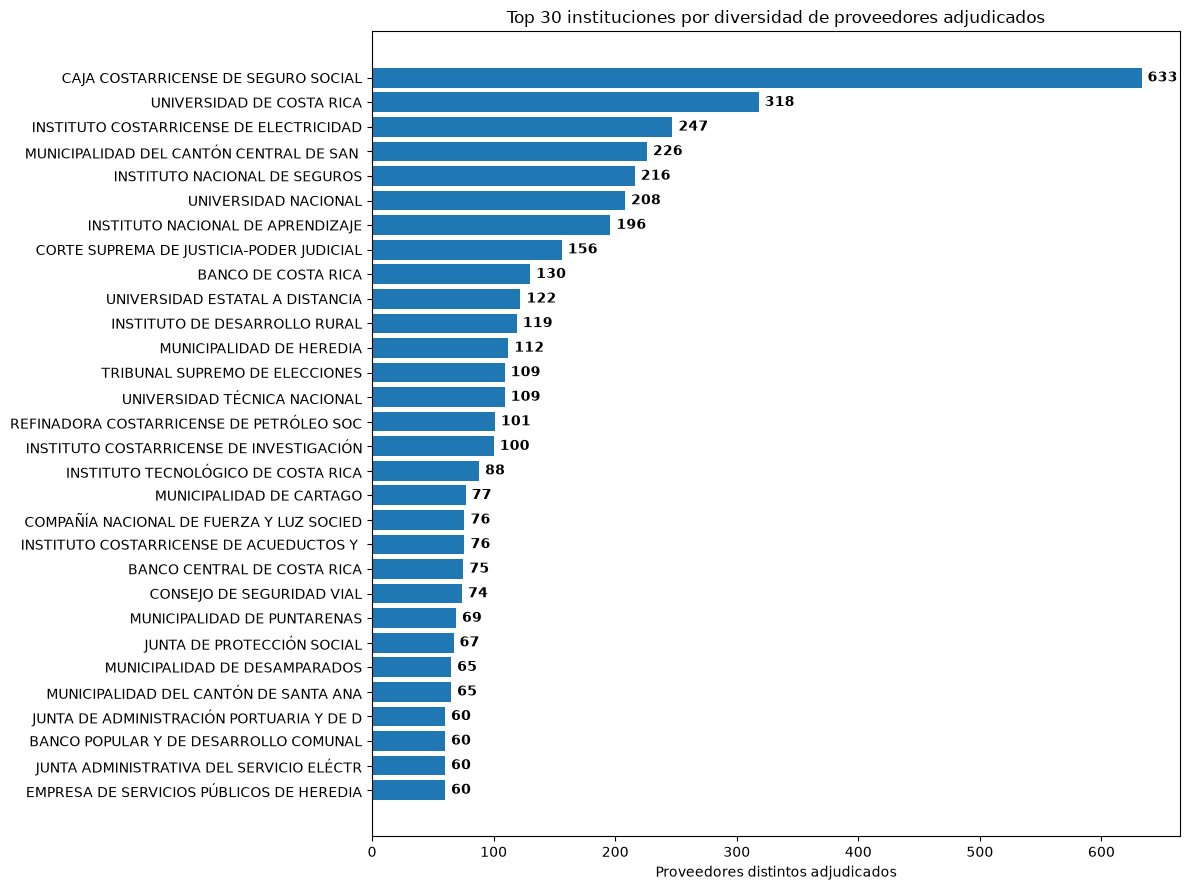

In [ ]:
df_proveedores_inst = con.execute("""
    SELECT
        a.cedula_institucion,
        i.nombre_institucion,
        COUNT(DISTINCT a.cedula_proveedor) AS proveedores_distintos
    FROM final.fact_lineas_adjudicadas a
    LEFT JOIN final.dim_instituciones i ON i.cedula = a.cedula_institucion
    GROUP BY a.cedula_institucion, i.nombre_institucion
    ORDER BY proveedores_distintos DESC
""").df()

top20 = df_proveedores_inst.head(30).copy()
etiquetas = top20["nombre_institucion"].fillna(top20["cedula_institucion"]).str.slice(0, 40)

fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(etiquetas[::-1], top20["proveedores_distintos"][::-1])
# Add annotation to bars
for i in ax.patches:
    plt.text(i.get_width()+5, i.get_y()+0.25,
             str(round((i.get_width()), 2)),
             fontsize=10, fontweight='bold',
             color='black')
ax.set_xlabel("Proveedores distintos adjudicados")
ax.set_title("Top 30 instituciones por diversidad de proveedores adjudicados")
plt.tight_layout()
plt.show()

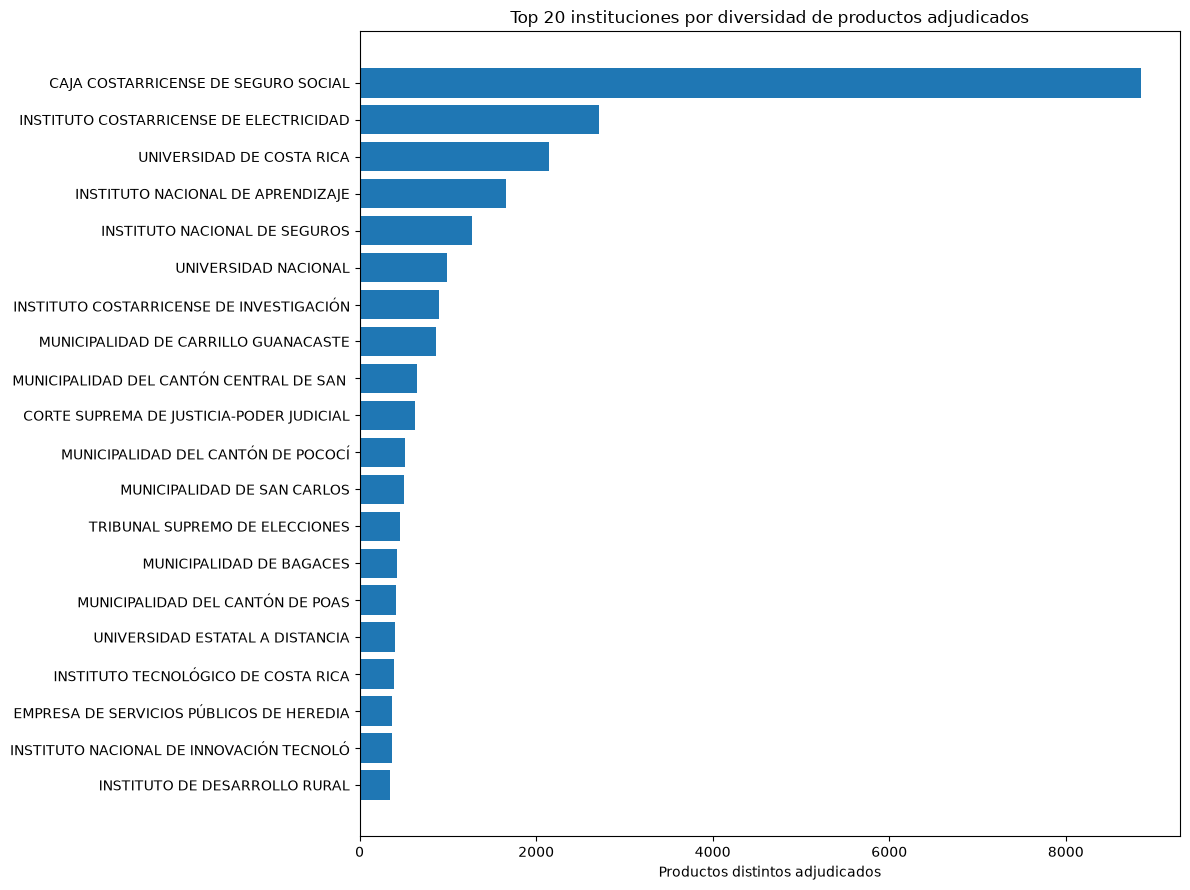

In [ ]:
df_productos_inst = con.execute("""
    SELECT
        a.cedula_institucion,
        i.nombre_institucion,
        COUNT(DISTINCT a.cod_producto) AS productos_distintos
    FROM final.fact_lineas_adjudicadas a
    LEFT JOIN final.dim_instituciones i ON i.cedula = a.cedula_institucion
    GROUP BY a.cedula_institucion, i.nombre_institucion
    ORDER BY productos_distintos DESC
""").df()

top20 = df_productos_inst.head(20).copy()
etiquetas = top20["nombre_institucion"].fillna(top20["cedula_institucion"]).str.slice(0, 40)

fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(etiquetas[::-1], top20["productos_distintos"][::-1])
ax.set_xlabel("Productos distintos adjudicados")
ax.set_title("Top 20 instituciones por diversidad de productos adjudicados")
plt.tight_layout()
plt.show()

   adjudicaciones_totales      desde      hasta
0                   56790 2025-01-02 2026-09-09


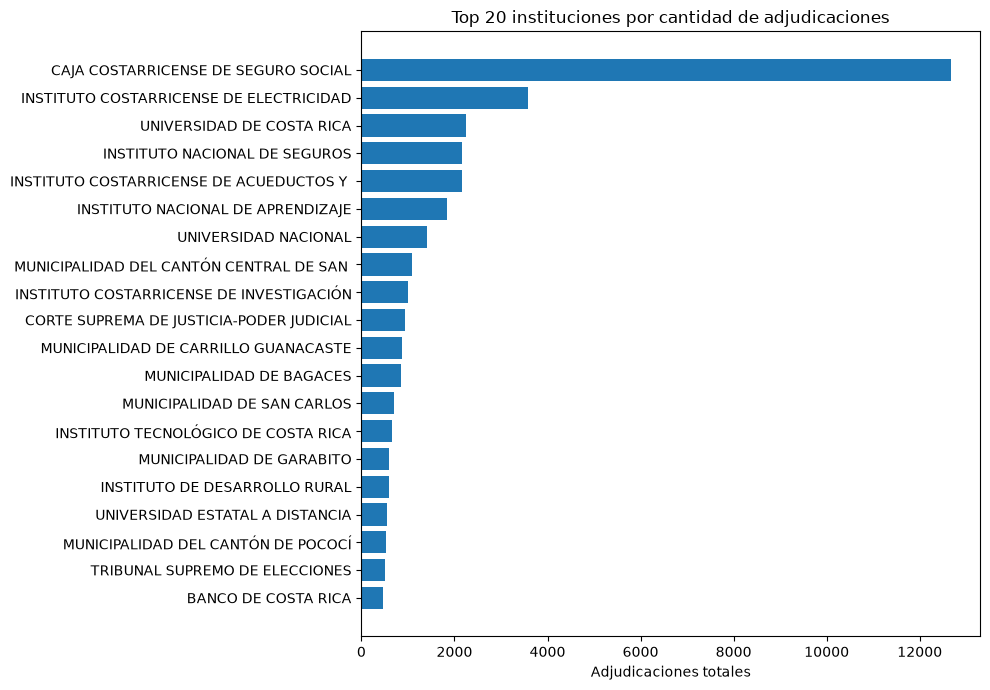

In [ ]:
resumen_periodo = con.execute("""
    SELECT
        COUNT(*) AS adjudicaciones_totales,
        MIN(fecha_adjudicacion) AS desde,
        MAX(fecha_adjudicacion) AS hasta
    FROM final.fact_lineas_adjudicadas
""").df()
print(resumen_periodo)

df_adjudicaciones_inst = con.execute("""
    SELECT
        a.cedula_institucion,
        i.nombre_institucion,
        COUNT(*) AS adjudicaciones_totales
    FROM final.fact_lineas_adjudicadas a
    LEFT JOIN final.dim_instituciones i ON i.cedula = a.cedula_institucion
    GROUP BY a.cedula_institucion, i.nombre_institucion
    ORDER BY adjudicaciones_totales DESC
""").df()

top20 = df_adjudicaciones_inst.head(20).copy()
etiquetas = top20["nombre_institucion"].fillna(top20["cedula_institucion"]).str.slice(0, 40)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(etiquetas[::-1], top20["adjudicaciones_totales"][::-1])
ax.set_xlabel("Adjudicaciones totales")
ax.set_title("Top 20 instituciones por cantidad de adjudicaciones")
plt.tight_layout()
plt.show()

In [ ]:
resumen_instituciones = (
    df_promedio_mensual
    .merge(df_proveedores_inst[["cedula_institucion", "proveedores_distintos"]], on="cedula_institucion", how="outer")
    .merge(df_productos_inst[["cedula_institucion", "productos_distintos"]], on="cedula_institucion", how="outer")
    .merge(df_adjudicaciones_inst[["cedula_institucion", "adjudicaciones_totales"]], on="cedula_institucion", how="outer")
    .sort_values("total_carteles", ascending=False)
)

resumen_instituciones.head(30)

#for i in resumen_instituciones.columns:
#   print(f"{i}: {resumen_instituciones[i].isnull().sum()} valores nulos")

,cedula_institucion,nombre_institucion,promedio_carteles_mes,meses_con_actividad,total_carteles,proveedores_distintos,productos_distintos,adjudicaciones_totales
372,4000042147,CAJA COSTARRICENSE DE SEGURO SOCIAL,330.95,21.0,6950.0,633.0,8851.0,12662.0
237,3014042058,MUNICIPALIDAD DEL CANTÓN CENTRAL DE SAN JOSÉ,80.90,21.0,1699.0,226.0,650.0,1081.0
374,4000042149,UNIVERSIDAD DE COSTA RICA,79.52,21.0,1670.0,318.0,2146.0,2244.0
21,2300042155,CORTE SUPREMA DE JUSTICIA-PODER JUDICIAL,77.05,21.0,1618.0,156.0,630.0,934.0
364,4000042139,INSTITUTO COSTARRICENSE DE ELECTRICIDAD,76.05,21.0,1597.0,247.0,2714.0,3584.0
379,4000045127,INSTITUTO NACIONAL DE APRENDIZAJE,63.19,21.0,1327.0,196.0,1664.0,1838.0
360,4000001902,INSTITUTO NACIONAL DE SEGUROS,53.10,21.0,1115.0,216.0,1278.0,2154.0
361,4000004017,BANCO CENTRAL DE COSTA RICA,40.14,21.0,843.0,75.0,72.0,218.0
207,3007556085,UNIVERSIDAD TÉCNICA NACIONAL,34.86,21.0,732.0,109.0,261.0,275.0
162,3007111111,COMISIÓN NACIONAL DE PREVENCIÓN DE RIESGOS Y A...,34.67,21.0,728.0,43.0,63.0,240.0


---
Ahora, creemos analíticas enfocadas en el comportamiento de los **productos** registrados.

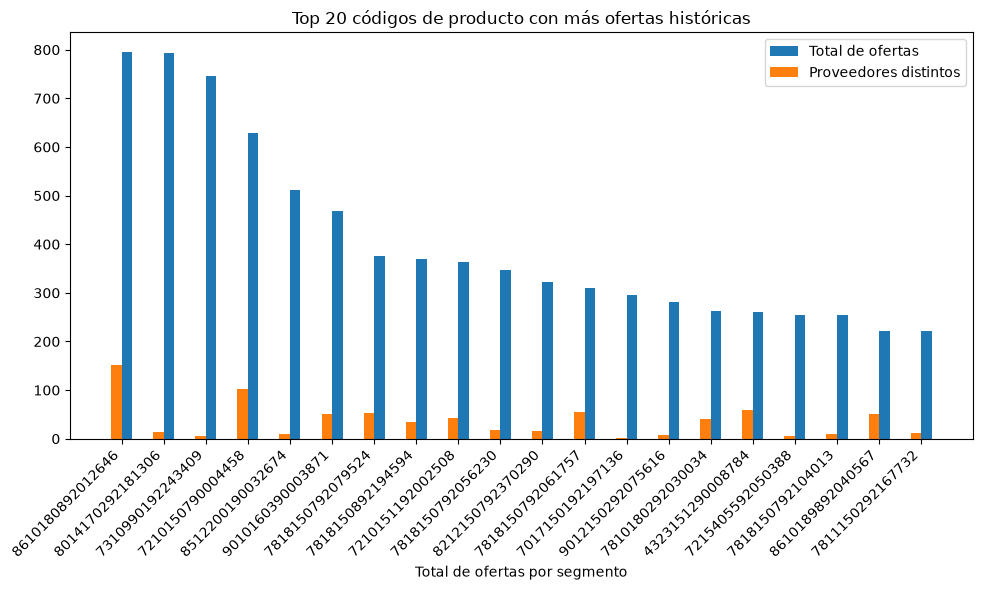

In [ ]:
# top productos por total de ofertas
df_productos = con.execute("""
    SELECT
        o.cod_producto,
        p.descripcion_producto,
        p.segmento,
        p.nombre_segmento,
        COUNT(*) AS total_ofertas,
        COUNT(DISTINCT o.nro_sicop || '-' || o.nro_linea) AS lineas_distintas,
        COUNT(DISTINCT o.cedula_proveedor) AS proveedores_distintos
    FROM final.fact_lineas_ofertas o
    LEFT JOIN final.dim_productos p ON p.cod_producto = TRY_CAST(o.cod_producto AS BIGINT)
    GROUP BY o.cod_producto, p.descripcion_producto, p.segmento, p.nombre_segmento
    ORDER BY total_ofertas DESC
""").df()

top20 = df_productos.head(20).copy()
top20["etiqueta"] = top20["descripcion_producto"].fillna(top20["cod_producto"]).str.slice(0, 40)

x = np.arange(len(top20["segmento"]))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(x + width/2, top20["total_ofertas"], width, label="Total de ofertas")
ax.bar(x - width/2, top20["proveedores_distintos"], width, label="Proveedores distintos")

ax.set_xlabel("Total de ofertas por segmento")
ax.set_title("Top 20 códigos de producto con más ofertas históricas")

ax.set_xticks(x)
ax.set_xticklabels(top20["cod_producto"], rotation=45, ha="right")


ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
# top segmentos por total de ofertas
df_segmentos = con.execute("""
    SELECT
        p.segmento,
        p.nombre_segmento,
        COUNT(*) AS total_ofertas,
        COUNT(DISTINCT o.nro_sicop || '-' || o.nro_linea) AS lineas_distintas,
        COUNT(DISTINCT o.cedula_proveedor) AS proveedores_distintos
    FROM final.fact_lineas_ofertas o
    LEFT JOIN final.dim_productos p ON p.cod_producto = TRY_CAST(o.cod_producto AS BIGINT)
    GROUP BY p.segmento, p.nombre_segmento
    ORDER BY total_ofertas DESC
""").df()

print(f"Total de segmentos con ofertas distintos: {len(df_segmentos)}")
top20 = df_segmentos.head(20)


Total de segmentos con ofertas distintos: 57


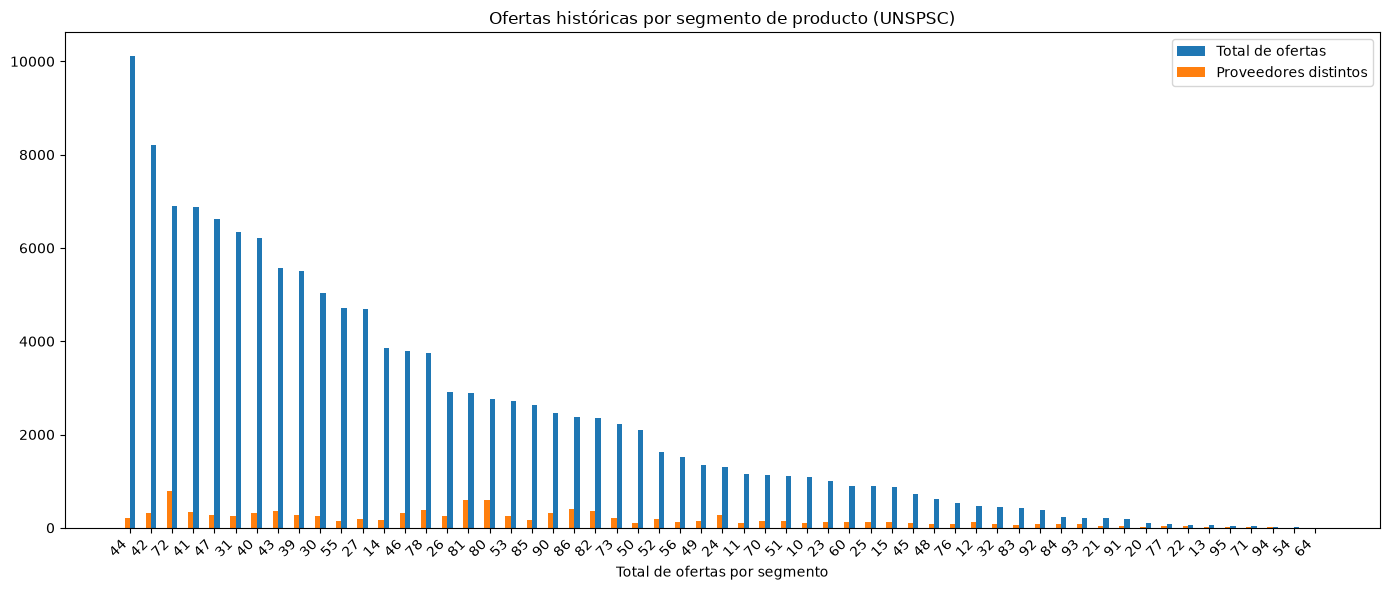

In [ ]:
x = np.arange(len(df_segmentos["segmento"]))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(x + width/2, df_segmentos["total_ofertas"], width, label="Total de ofertas")
ax.bar(x - width/2, df_segmentos["proveedores_distintos"], width, label="Proveedores distintos")

ax.set_xlabel("Total de ofertas por segmento")
ax.set_title("Ofertas históricas por segmento de producto (UNSPSC)")

ax.set_xticks(x)
ax.set_xticklabels(df_segmentos["segmento"], rotation=45, ha="right")

ax.legend()

plt.tight_layout()
plt.show()

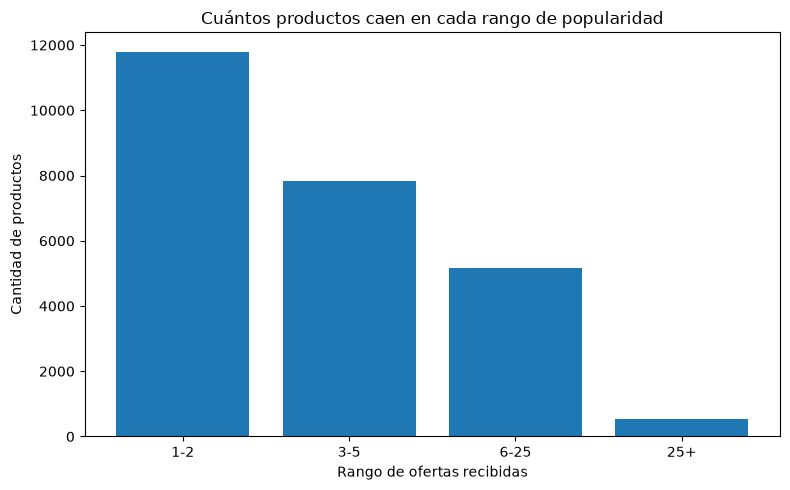

In [ ]:
df_buckets = con.execute("""
    WITH ofertas_por_producto AS (
        SELECT cod_producto, COUNT(*) AS total_ofertas
        FROM final.fact_lineas_ofertas
        GROUP BY cod_producto
    )
    SELECT
        CASE
            WHEN total_ofertas BETWEEN 1 AND 2   THEN '1-2'
            WHEN total_ofertas BETWEEN 3 AND 5   THEN '3-5'
            WHEN total_ofertas BETWEEN 6 AND 25  THEN '6-25'
            ELSE '25+'
        END AS rango_ofertas,
        COUNT(*) AS cantidad_productos
    FROM ofertas_por_producto
    GROUP BY 1
""").df()

orden = ["1-2", "3-5", "6-25", "25+"]
df_buckets["rango_ofertas"] = pd.Categorical(df_buckets["rango_ofertas"], categories=orden, ordered=True)
df_buckets = df_buckets.sort_values("rango_ofertas")

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(df_buckets["rango_ofertas"].astype(str), df_buckets["cantidad_productos"])
ax.set_xlabel("Rango de ofertas recibidas")
ax.set_ylabel("Cantidad de productos")
ax.set_title("Cuántos productos caen en cada rango de popularidad")
plt.tight_layout()
plt.show()

In [ ]:
con.sql("""
    SELECT *
    FROM final.dim_proveedores
    LIMIT 5
""").df()

,cedula_proveedor,nombre_proveedor,tipo_proveedor,tamano_proveedor,zona_geo_prov,fecha_registro,porcentaje_exito,productos_distintos_ofertados
0,9000018810,ALBERTO CADAVID R. & CIA. S.A,Extranjero Jurídico,Grande,", ,",2025-05-02,NaN,0
1,3101411180,DATASOFT NETSOLUTIONS SOCIEDAD ANONIMA,Nacional Jurídico,Pequeña,"Mata de Plátano, Goicoechea, San José",2010-07-01,0.583333,10
2,3101163507,TECNOLOGIA E INGENIERIA VERDE SOCIEDAD ANONIMA,Nacional Jurídico,Pequeña,"Granadilla, Curridabat, San José",2010-10-28,0.666667,3
3,3101445916,REDES FUSIONET SOCIEDAD ANONIMA,Nacional Jurídico,Mediana,"San Pedro, Montes de Oca, San José",2011-01-04,0.500000,15
4,303740958,JIMMY ALEJANDRO SANCHEZ GOMEZ,Nacional Físico,Pequeña,"San José, Grecia, Alajuela",2011-03-02,0.777778,32


In [ ]:
# Cantidad de proveedores por tamaño
con.execute("""
    SELECT
        tamano_proveedor,
        COUNT(*) AS cantidad_proveedores
    FROM final.dim_proveedores
    GROUP BY tamano_proveedor
    ORDER BY cantidad_proveedores DESC
""").df()

,tamano_proveedor,cantidad_proveedores
0,Pequeña,19901
1,Microemprendedor,19754
2,Grande,10577
3,Mediana,7167
4,No clasificado,1007


---
Ahora, exploremos los datos presentes en **fact lineas carteles**.

In [ ]:
# Cantidad de carteles por tipo de procedimiento
con.execute("""
    SELECT
        tipo_procedimiento,
        COUNT(*) AS cantidad_lineas_carteles
    FROM final.fact_lineas_carteles
    GROUP BY tipo_procedimiento
    ORDER BY cantidad_lineas_carteles DESC
""").df()

,tipo_procedimiento,cantidad_lineas_carteles
0,LICITACIÓN REDUCIDA,193914
1,LICITACIÓN MENOR,55706
2,LICITACIÓN MAYOR,47397
3,PROCEDIMIENTOS ESPECIALES,31144
4,PROCEDIMIENTO POR EXCEPCIÓN,27712
5,REMATE,1162
6,SUBASTA INVERSA ELECTRÓNICA,295
7,LICITACIÓN PÚBLICA NACIONAL,1


In [ ]:
#3. ¿Qué porcentaje de líneas de cartel no tiene NINGUNA oferta?
con.sql("""
SELECT
    COUNT(*) AS total_lineas_cartel,
    COUNT(*) FILTER (WHERE o.n IS NULL) AS sin_ofertas,
    ROUND(100.0 * COUNT(*) FILTER (WHERE o.n IS NULL) / COUNT(*), 1) AS pct_sin_ofertas
FROM final.fact_lineas_carteles c
LEFT JOIN (
    SELECT nro_sicop, nro_linea, COUNT(*) AS n
    FROM final.fact_lineas_ofertas
    GROUP BY nro_sicop, nro_linea
) o ON o.nro_sicop = c.nro_sicop AND o.nro_linea = c.numero_linea;
""").df()

,total_lineas_cartel,sin_ofertas,pct_sin_ofertas
0,357331,314609,88.0


In [ ]:
#4. En promedio, ¿cuántas líneas cubre una sola oferta?
con.sql("""
SELECT 
    MAX(lineas_por_oferta) AS maximo,
    MIN(lineas_por_oferta) AS minimo,
    AVG(lineas_por_oferta) AS promedio,
    COUNT(*) AS total_ofertas
FROM (SELECT nro_oferta, COUNT(*) AS lineas_por_oferta
      FROM final.fact_lineas_ofertas GROUP BY nro_oferta)
""").df()

,maximo,minimo,promedio,total_ofertas
0,99,1,1.749445,75704


---
Estadísticas sobre precios en **ofertas**.

In [ ]:
con.sql("""
    SELECT *
    FROM final.fact_lineas_ofertas
    LIMIT 5
""").df()

,nro_sicop,nro_oferta,nro_linea,cedula_proveedor,fecha_oferta,tipo_oferta,cod_producto,cantidad_ofertada,precio_unitario_ofertado,tipo_moneda,tipo_cambio_crc,monto_linea,radio_competitividad
0,20250202257,D20250307081454334217413568942730,5,3101516974,2025-03-07,Individual,1411150792007810,1.0,1590.000000,CRC,507.42,1590.000000,1.628931e+00
1,20250200111,D20250217100237138617398081579510,69,3101661822,2025-02-17,Individual,4410240292125688,1.0,14250.000000,CRC,509.50,14250.000000,1.097408e+00
2,20250200111,D20250217100237138617398081579510,76,3101661822,2025-02-17,Individual,4412201292313729,1.0,3100.000000,CRC,509.50,3100.000000,5.974194e-01
3,20250200306,D20250214071304366417395387846010,276,3101162608,2025-02-14,Individual,4112170292114815,5.0,57.940000,USD,508.98,147451.506000,1.424197e+00
4,20250200306,D20250213170520257617394879207720,38,3101257737,2025-02-13,Individual,4112210192411988,5.0,0.000001,CRC,508.98,0.000005,4.000000e+10


In [ ]:
con.sql("""
    SELECT
        MIN(monto_linea) AS minimo,
        MAX(monto_linea) AS maximo,
        AVG(monto_linea) AS promedio,
        MEDIAN(monto_linea) AS mediana
    FROM final.fact_lineas_ofertas
""").df()

,minimo,maximo,promedio,mediana
0,0.0,1.687973e+11,9.676113e+06,120000.0


---

## 2. Evaluación del clasificador de adjudicación (Random Forest)

En esta sección se experimenta **en local** con el modelo.
Para facilitar la implementación a producción se reutilizan las mismas variables,
las mismas consultas de entrenamiento y el mismo pipeline de preprocesamiento
que `modelo/entrena_y_predice.py` utiliza. Esto para que, lo que se mida acá, sea
comparable con lo que corre en el workflow diario de Acciones de GitHub.

**Supuesto de ubicación:** este notebook asume que vive en la raíz del
repositorio (junto a `etl/`, `modelo/`, `requirements.txt`) y que Jupyter se
lanzó desde ahí, para poder hacer `from modelo.entrena_y_predice import ...`
directamente. Si se ubica en otra carpeta, será necesario modificar la `RAIZ_PROYECTO` en la
siguiente celda.

In [ ]:
import sys
from pathlib import Path

# Asume que este notebook se ejecuta desde la raíz del proyecto, y agrega la raíz del proyecto al path de Python para poder importar los módulos del proyecto.
RAIZ_PROYECTO = Path.cwd() 
if str(RAIZ_PROYECTO) not in sys.path:
    sys.path.insert(0, str(RAIZ_PROYECTO))

#si deseas correr este notebook desde Google Colab, descomenta la siguiente línea y comenta las anteriores
#!git clone https://github.com/ssolorzanocr/Modelo_predictivo_SICOP.git
#sys.path.append('/content/Modelo_predictivo_SICOP/modelo')
#!ls /content/Modelo_predictivo_SICOP/modelo/

In [2]:
import duckdb
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    RocCurveDisplay,
    PrecisionRecallDisplay,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    accuracy_score,
)

# Reutiliza las variables, la consulta, el pipeline Y el criterio de split
# de producción -- así este notebook no puede quedar desincronizado del
# modelo real sin que se note.
from modelo.entrena_y_predice import (
    BUFFER_DIAS_DECISION,
    COLUMNAS_CATEGORICAS,
    COLUMNAS_NUMERICAS,
    CONSULTA_ENTRENAMIENTO,
    construir_pipeline,
    dividir_train_test_cronologico,
)

print("Categóricas:", COLUMNAS_CATEGORICAS)
print("Numéricas:", COLUMNAS_NUMERICAS)
print(f"Buffer de decisión: {BUFFER_DIAS_DECISION} días")

Categóricas: ['tamano_proveedor', 'segmento', 'tipo_procedimiento']
Numéricas: ['proveedores_adjudicados_distintos', 'porcentaje_exito_historico', 'radio_competitividad', 'productos_distintos_historico', 'cantidad_solicitada', 'cantidad_ofertada']
Buffer de decisión: 90 días


### 2.1. Construcción de los datasets de entrenamiento y prueba

Se corre la misma `CONSULTA_ENTRENAMIENTO` que usa el workflow diario --
que ya excluye las ofertas sin decisión todavía confiable (menos de
`BUFFER_DIAS_DECISION` desde `fecha_oferta` y sin adjudicación registrada).

El split ya **no es aleatorio**: `dividir_train_test_cronologico` ordena
por `fecha_oferta` y deja lo más antiguo en entrenamiento, lo más reciente
en prueba -- imitando cómo se usa el modelo en producción (predecir el
futuro con el pasado, nunca al revés).

In [3]:
from dotenv import load_dotenv
import os

load_dotenv()

RUTA_BASE_DE_DATOS = os.getenv("RUTA_DATOS")
print(f"Ruta de la base de datos: {RUTA_BASE_DE_DATOS}")

con = duckdb.connect(str(RUTA_BASE_DE_DATOS), read_only=True)

df = con.execute(CONSULTA_ENTRENAMIENTO).df()
print(f"Filas totales: {len(df):,}")
df.head()

Ruta de la base de datos: localdata\sicop.duckdb
Filas totales: 131,572


,tamano_proveedor,segmento,tipo_procedimiento,proveedores_adjudicados_distintos,porcentaje_exito_historico,radio_competitividad,productos_distintos_historico,cantidad_solicitada,cantidad_ofertada,fecha_oferta,fue_adjudicado
0,Pequeña,73,LICITACIÓN REDUCIDA,128,0.267857,1.020000,57,10.0,10.0,2025-09-09,True
1,Grande,40,LICITACIÓN REDUCIDA,205,0.187500,3.406710,93,6.0,6.0,2025-10-01,True
2,Mediana,42,LICITACIÓN REDUCIDA,645,0.300000,1.005168,12,1.0,1.0,2025-09-12,True
3,Pequeña,10,LICITACIÓN REDUCIDA,21,0.000000,1.610777,1,4.0,4.0,2025-09-19,True
4,Grande,72,LICITACIÓN REDUCIDA,645,0.333333,0.909160,10,1.0,1.0,2025-09-23,True


In [4]:
df["fue_adjudicado"] = df["fue_adjudicado"].astype(bool)

train_df, test_df = dividir_train_test_cronologico(df)

print(f"Entrenamiento: {len(train_df):,} filas, "
      f"de {train_df['fecha_oferta'].min()} a {train_df['fecha_oferta'].max()}")
print(f"Prueba: {len(test_df):,} filas, "
      f"de {test_df['fecha_oferta'].min()} a {test_df['fecha_oferta'].max()}")

y_train = train_df.pop("fue_adjudicado")
X_train = train_df[COLUMNAS_CATEGORICAS + COLUMNAS_NUMERICAS]
y_test = test_df.pop("fue_adjudicado")
X_test = test_df[COLUMNAS_CATEGORICAS + COLUMNAS_NUMERICAS]

Entrenamiento: 105,257 filas, de 2025-01-07 00:00:00 a 2026-03-19 00:00:00
Prueba: 26,315 filas, de 2026-03-19 00:00:00 a 2026-09-10 00:00:00


### Balance de clases

Antes de mirar cualquier métrica, vale la pena confirmar qué tan balanceado
está el problema. Si una clase domina mucho, `accuracy` sola puede ser
engañosa -- por eso las secciones de abajo usan `roc_auc` como métrica
principal de ajuste, no `accuracy`.

fue_adjudicado
False    0.683841
True     0.316159
Name: proportion, dtype: float64


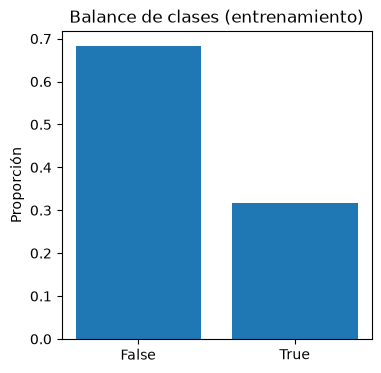

In [5]:
proporcion_clases = y_train.value_counts(normalize=True)
print(proporcion_clases)

fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(proporcion_clases.index.astype(str), proporcion_clases.values)
ax.set_ylabel("Proporción")
ax.set_title("Balance de clases (entrenamiento)")
plt.show()

### 2.2. Ajuste de hiperparámetros

Se usa `RandomizedSearchCV` en vez de una búsqueda exhaustiva (`GridSearchCV`)
porque el espacio de combinaciones es grande -- prueba una muestra aleatoria
de combinaciones en vez de todas, con validación cruzada de 5 particiones.

La métrica de ajuste es `roc_auc`, no `accuracy` -- por la razón de la
sección anterior. El nombre del parámetro (`clasificador__...`) tiene el
prefijo `clasificador__` porque así se llama ese paso dentro del `Pipeline`
que ya viene armado en `construir_pipeline()`.

In [6]:
param_distributions = {
    "clasificador__n_estimators": [10, 20, 50, 100, 150, 200, 300, 400],
    "clasificador__max_depth": [None, 5, 10, 15, 20, 30],
    "clasificador__min_samples_leaf": [1, 2, 5, 10, 20],
    "clasificador__max_features": ["sqrt", "log2", None],
}

busqueda = RandomizedSearchCV(
    estimator=construir_pipeline(),
    param_distributions=param_distributions,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

busqueda.fit(X_train, y_train)

print("Mejores hiperparámetros:", busqueda.best_params_)
print(f"Mejor AUC promedio (validación cruzada): {busqueda.best_score_:.3f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores hiperparámetros: {'clasificador__n_estimators': 150, 'clasificador__min_samples_leaf': 2, 'clasificador__max_features': 'log2', 'clasificador__max_depth': 10}
Mejor AUC promedio (validación cruzada): 0.715


### Resultados de la búsqueda

Un vistazo a las mejores combinaciones probadas, para ver qué tan sensible
es el resultado a cada hiperparámetro (si varias combinaciones distintas dan
un AUC parecido, probablemente cualquiera de ellas sirve igual de bien).

In [ ]:
resultados = pd.DataFrame(busqueda.cv_results_)
resultados = resultados.sort_values("mean_test_score", ascending=False)

columnas_interes = [c for c in resultados.columns if c.startswith("param_")] + [
    "mean_test_score", "std_test_score"
]
top10 = resultados[columnas_interes].head(10)
resultados[columnas_interes]

,param_clasificador__n_estimators,param_clasificador__min_samples_leaf,param_clasificador__max_features,param_clasificador__max_depth,mean_test_score,std_test_score
8,150,2,log2,10,0.714989,0.034348
14,300,10,log2,15,0.714861,0.032578
9,300,10,sqrt,15,0.714445,0.032409
1,50,2,log2,10,0.712985,0.033213
18,100,5,sqrt,10,0.711688,0.032795
12,400,20,sqrt,None,0.711298,0.030032
6,400,5,log2,None,0.710946,0.026777
17,100,10,sqrt,30,0.710580,0.027228
5,20,10,log2,None,0.706431,0.028733
3,300,20,log2,5,0.703256,0.036376


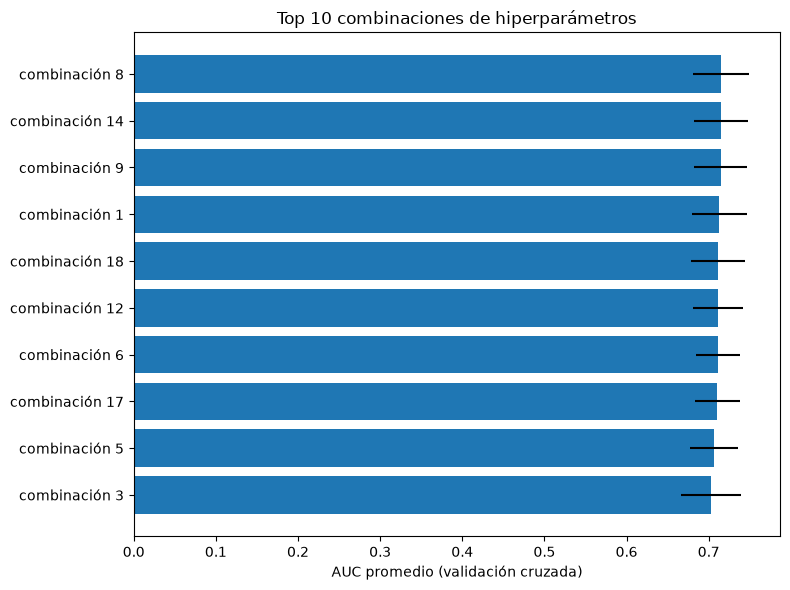

In [8]:
top10_grafico = resultados.head(10).iloc[::-1]
etiquetas = [f"combinación {i}" for i in top10_grafico.index]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(etiquetas, top10_grafico["mean_test_score"],
        xerr=top10_grafico["std_test_score"])
ax.set_xlabel("AUC promedio (validación cruzada)")
ax.set_title("Top 10 combinaciones de hiperparámetros")
plt.tight_layout()
plt.show()

### 2.3. Validación con curva ROC

Con el mejor modelo encontrado (`busqueda.best_estimator_`), ya reentrenado
internamente sobre todo `X_train`, se evalúa sobre el conjunto de **prueba**
-- datos que la búsqueda de hiperparámetros nunca vio.

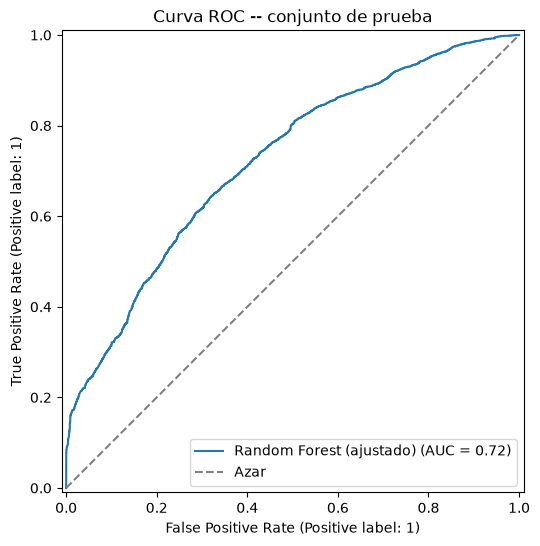

AUC en conjunto de prueba: 0.722


In [9]:
mejor_modelo = busqueda.best_estimator_
probabilidades_test = mejor_modelo.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(
    y_test, probabilidades_test, ax=ax, name="Random Forest (ajustado)"
)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
ax.set_title("Curva ROC -- conjunto de prueba")
ax.legend()
plt.show()

print(f"AUC en conjunto de prueba: {roc_auc_score(y_test, probabilidades_test):.3f}")

### Curva Precision-Recall (complemento a la ROC)

Si el balance de clases de la sección 1 salió bastante desigual, la curva
ROC puede verse "mejor de lo que es" -- Precision-Recall es más sensible a
ese desbalance y suele dar una imagen más honesta en estos casos.

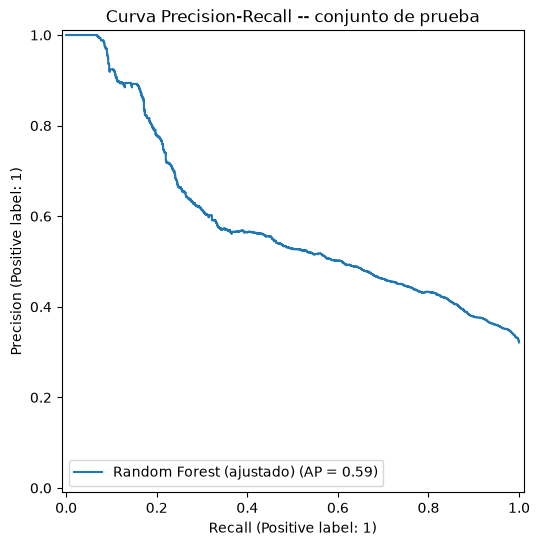

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))
PrecisionRecallDisplay.from_predictions(
    y_test, probabilidades_test, ax=ax, name="Random Forest (ajustado)"
)
ax.set_title("Curva Precision-Recall -- conjunto de prueba")
plt.show()

### 2.4. Evaluación del desempeño con el conjunto de prueba

Métricas de clasificación "dura" (con el umbral por defecto de 0.5), y
comparación contra un modelo ingenuo que siempre prediga la clase
mayoritaria -- así se ve si el modelo realmente aprendió algo por encima de
lo obvio.

In [11]:
predicciones_test = mejor_modelo.predict(X_test)

exactitud = accuracy_score(y_test, predicciones_test)
baseline_ingenuo = y_train.value_counts(normalize=True).max()

print(f"Exactitud (accuracy) del modelo:  {exactitud:.3f}")
print(f"Baseline ingenuo (clase mayoritaria): {baseline_ingenuo:.3f}")
print()
print(classification_report(
    y_test, predicciones_test, target_names=["no_adjudicado", "adjudicado"]
))

Exactitud (accuracy) del modelo:  0.713
Baseline ingenuo (clase mayoritaria): 0.684

               precision    recall  f1-score   support

no_adjudicado       0.70      0.99      0.82     17857
   adjudicado       0.89      0.12      0.21      8458

     accuracy                           0.71     26315
    macro avg       0.80      0.56      0.52     26315
 weighted avg       0.77      0.71      0.63     26315



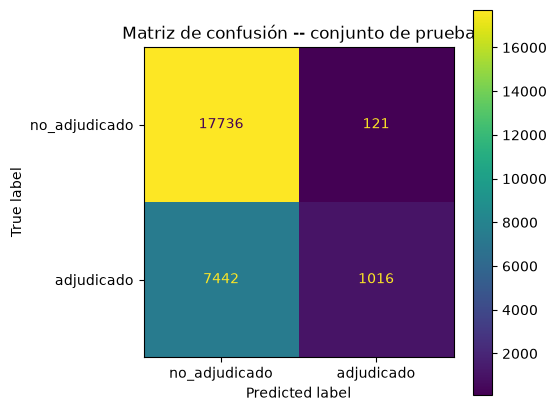

In [12]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, predicciones_test, ax=ax,
    display_labels=["no_adjudicado", "adjudicado"],
)
ax.set_title("Matriz de confusión -- conjunto de prueba")
plt.show()

### 2.5. Importancia de variables

Cuáles de las nuevas variables (`tamano_proveedor`, `segmento`,
`tipo_procedimiento`, los indicadores de institución/proveedor,
`radio_competitividad`, etc.) están realmente aportando al modelo.

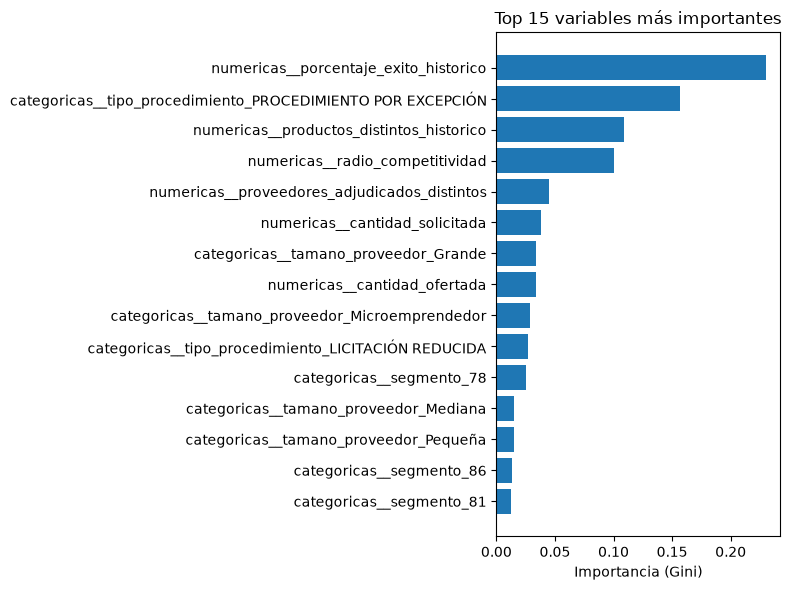

,variable,importancia
67,numericas__porcentaje_exito_historico,0.230571
64,categoricas__tipo_procedimiento_PROCEDIMIENTO ...,0.157062
69,numericas__productos_distintos_historico,0.108536
68,numericas__radio_competitividad,0.100785
66,numericas__proveedores_adjudicados_distintos,0.044591
70,numericas__cantidad_solicitada,0.038408
0,categoricas__tamano_proveedor_Grande,0.034026
71,numericas__cantidad_ofertada,0.033784
2,categoricas__tamano_proveedor_Microemprendedor,0.028334
63,categoricas__tipo_procedimiento_LICITACIÓN RED...,0.026584


In [13]:
nombres_columnas = mejor_modelo.named_steps["preprocesamiento"].get_feature_names_out()
importancias = mejor_modelo.named_steps["clasificador"].feature_importances_

df_importancias = (
    pd.DataFrame({"variable": nombres_columnas, "importancia": importancias})
    .sort_values("importancia", ascending=False)
)

top15 = df_importancias.head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top15["variable"], top15["importancia"])
ax.set_xlabel("Importancia (Gini)")
ax.set_title("Top 15 variables más importantes")
plt.tight_layout()
plt.show()

df_importancias.head(15)